<a href="https://colab.research.google.com/github/lakatosgabor/total_active_power_anomaly_detctor/blob/main/total_active_power_anomaly_detctor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### How to run the code?
Download the dataset to your computer from the link below: https://doi.org/10.5281/zenodo.20338544

Upload the dataset to the Google Colab (temporary) storage (left sidebar).

Run the cells from top to bottom.

### Imports the used modules


In [ ]:
import pandas as pd
import numpy as np
from numpy.ma.core import default_fill_value
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import scipy
from scipy.signal import savgol_filter, detrend, find_peaks
import sklearn
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from scipy.stats import mannwhitneyu

print(f"Pandas version:       {pd.__version__}")
print(f"NumPy version:        {np.__version__}")
print(f"Matplotlib version:   {plt.matplotlib.__version__}")
print(f"Seaborn version:      {sns.__version__}")
print(f"SciPy version:        {scipy.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"TensorFlow version:   {tf.__version__}")

pd.set_option('display.float_format', lambda x: f'{x:f}')

Pandas version:       2.2.2
NumPy version:        2.0.2
Matplotlib version:   3.10.0
Seaborn version:      0.13.2
SciPy version:        1.16.3
Scikit-learn version: 1.6.1
TensorFlow version:   2.20.0


### Load the active power and production test dataset (Shelly + MES)

In [ ]:
file_path = "/content/drive/MyDrive/PhD/Saját cikkek/4. Energiafelhasználás ellenőrzés/test_dataset.csv"

In [ ]:
df = pd.read_csv(file_path)
df = df[df['DEVICE_ID'] == 'shellypro3em-a0dd6c9f5048']
df['OBSERVATION_TIME'] = pd.to_datetime(df['OBSERVATION_TIME'])
df = df[df['OBSERVATION_TIME'].dt.hour < 12]
print('Lines: ', len(df))
df.head(10)[['DEVICE_ID', 'TOTAL_ACT_POWER', 'OBSERVATION_TIME', 'MACHINENAME', 'PRODUCTIONSTATUS_NAME', 'PRODUCTION_STATUS', 'PRODNAME', 'ACTUALQUANTITY', 'ACTUALSCRAP']]

Lines:  2463


,DEVICE_ID,TOTAL_ACT_POWER,OBSERVATION_TIME,MACHINENAME,PRODUCTIONSTATUS_NAME,PRODUCTION_STATUS,PRODNAME,ACTUALQUANTITY,ACTUALSCRAP
0,shellypro3em-a0dd6c9f5048,3911.490000,2025-07-14 07:59:59,FGP085,14_Termelés,2,A-PROD,418864.000000,528.000000
1,shellypro3em-a0dd6c9f5048,6547.255000,2025-07-14 08:00:03,FGP085,14_Termelés,2,A-PROD,418864.000000,528.000000
2,shellypro3em-a0dd6c9f5048,3777.296000,2025-07-14 08:00:08,FGP085,14_Termelés,2,A-PROD,418880.000000,528.000000
3,shellypro3em-a0dd6c9f5048,3760.793000,2025-07-14 08:00:12,FGP085,14_Termelés,2,A-PROD,418880.000000,528.000000
4,shellypro3em-a0dd6c9f5048,3236.197000,2025-07-14 08:00:17,FGP085,14_Termelés,2,A-PROD,418880.000000,528.000000
5,shellypro3em-a0dd6c9f5048,6172.717000,2025-07-14 08:00:21,FGP085,14_Termelés,2,A-PROD,418896.000000,528.000000
6,shellypro3em-a0dd6c9f5048,5963.292000,2025-07-14 08:00:26,FGP085,14_Termelés,2,A-PROD,418896.000000,528.000000
7,shellypro3em-a0dd6c9f5048,3669.413000,2025-07-14 08:00:30,FGP085,14_Termelés,2,A-PROD,418912.000000,528.000000
8,shellypro3em-a0dd6c9f5048,5899.063000,2025-07-14 08:00:35,FGP085,14_Termelés,2,A-PROD,418912.000000,528.000000
9,shellypro3em-a0dd6c9f5048,5676.702000,2025-07-14 08:00:39,FGP085,14_Termelés,2,A-PROD,418928.000000,528.000000


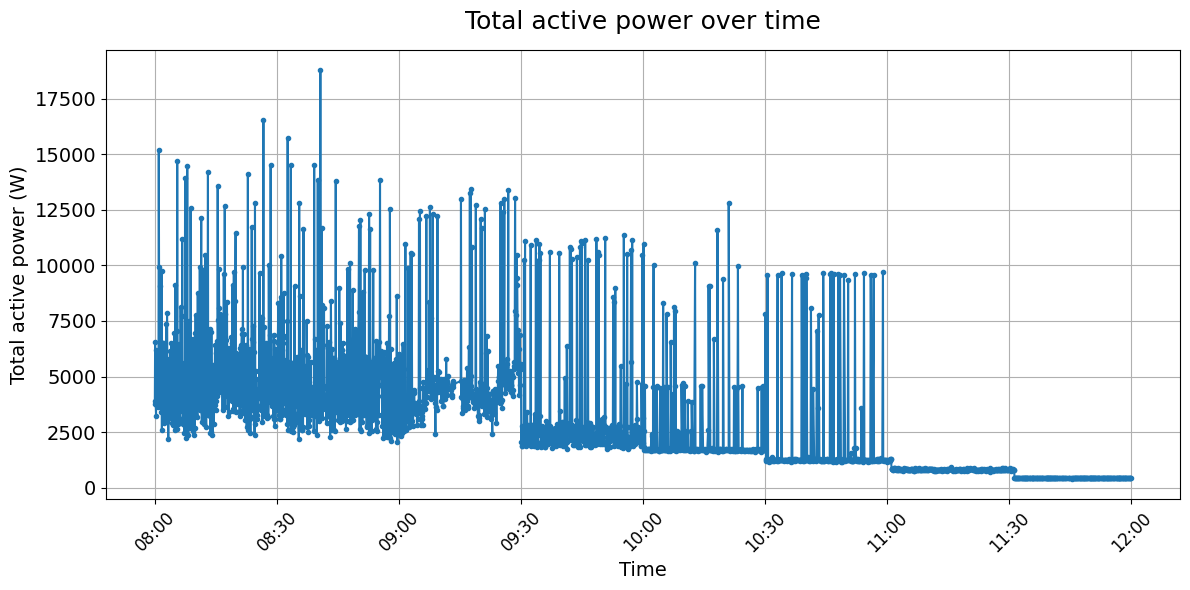

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    df['OBSERVATION_TIME'],
    df['TOTAL_ACT_POWER'],
    marker='o',
    linestyle='-',
    markersize=3
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.title('Total active power over time', fontsize=18, pad=15)

plt.xlabel('Time', fontsize=14)
plt.ylabel('Total active power (W)', fontsize=14)


plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=14)

plt.grid(True)
plt.tight_layout()
plt.show()

### Analyse test dataset



Average cycle time: 10.53 sec


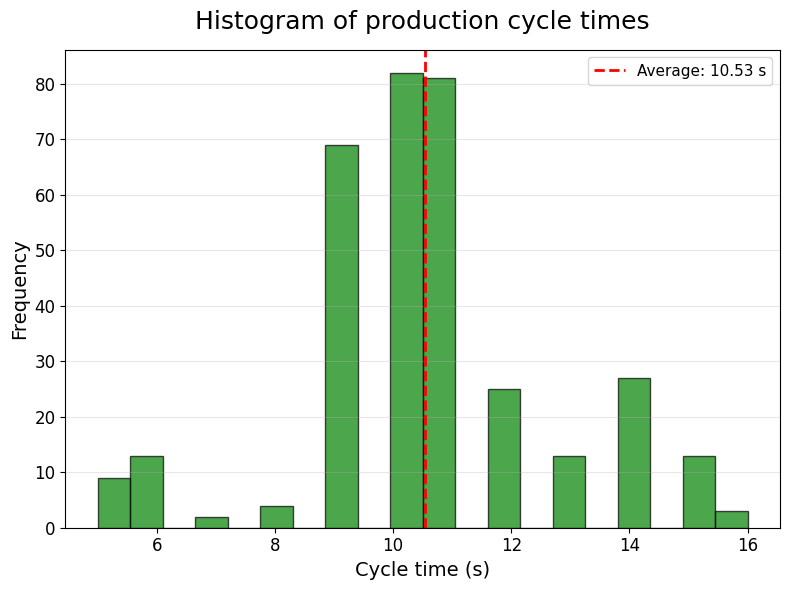

In [ ]:
df_plot = df.head(720).sort_values('OBSERVATION_TIME').reset_index(drop=True)

df_change = df_plot[df_plot['ACTUALQUANTITY'].diff() > 0]

cycle_times = df_change['OBSERVATION_TIME'].diff().dt.total_seconds().dropna()

avg_cycle = cycle_times.mean()
print(f'Average cycle time: {avg_cycle:.2f} sec')

plt.figure(figsize=(8,6))
plt.hist(cycle_times, bins=20, color='green', alpha=0.7, edgecolor='black')

plt.axvline(avg_cycle, color='red', linestyle='--', linewidth=2, label=f'Average: {avg_cycle:.2f} s')

plt.title('Histogram of production cycle times', fontsize=18, pad=15)

plt.xlabel('Cycle time (s)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

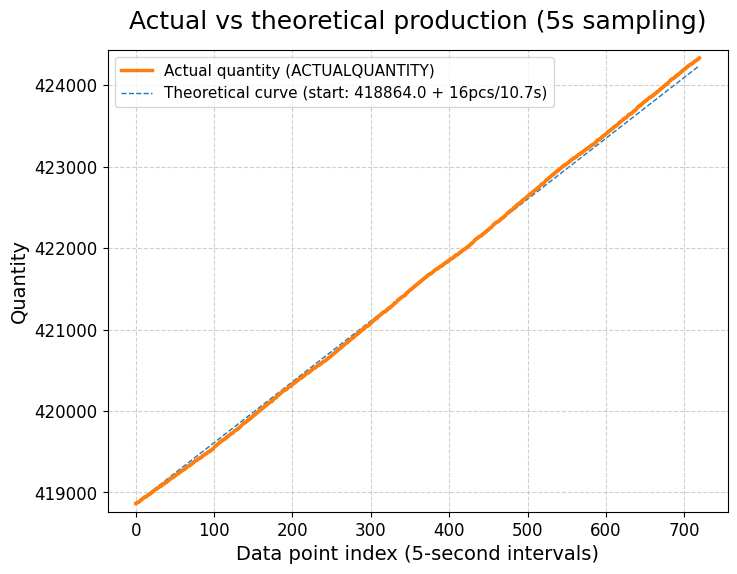

Number of data points: 720
Last actual value: 424336.0
Last theoretical value: 424239.7
Difference: 96.3
Cycles: 6.0


In [ ]:
start_quantity = 418864.0
sampling_time = 5
cycle_time_seconds = 10.7
parts_per_cycle = 16

df_final = df_plot.copy().reset_index(drop=True)
indices = df_final.index

elapsed_seconds = indices * sampling_time
theoretical_curve = start_quantity + (elapsed_seconds / cycle_time_seconds * parts_per_cycle)

plt.figure(figsize=(8, 6))

plt.plot(indices, df_final['ACTUALQUANTITY'],
         label="Actual quantity (ACTUALQUANTITY)",
         color='tab:orange',
         linewidth=2.5,
         zorder=2)

plt.plot(indices, theoretical_curve,
         label=f"Theoretical curve (start: {start_quantity} + 16pcs/10.7s)",
         color='tab:blue',
         linestyle='--',
         linewidth=1,
         zorder=1)

plt.xlabel("Data point index (5-second intervals)", fontsize=14)
plt.ylabel("Quantity", fontsize=14)
plt.title("Actual vs theoretical production (5s sampling)", fontsize=18, pad=15) # pad: kis távolság a címnél

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.ylim(start_quantity - 100, max(df_final['ACTUALQUANTITY'].max(), theoretical_curve.max()) + 100)

plt.show()

last_idx = len(df_final) - 1
print(f"Number of data points: {len(df_final)}")
print(f"Last actual value: {df_final['ACTUALQUANTITY'].iloc[-1]}")
print(f"Last theoretical value: {theoretical_curve[last_idx]:.1f}")
dif = df_final['ACTUALQUANTITY'].iloc[-1] - theoretical_curve[last_idx]
print(f"Difference: {dif:.1f}")
print(f"Cycles: {dif/16:.1f}")

### SG

In [ ]:
def sg_smooth(active_power_series, window_length=33, polyorder=3):
    if window_length % 2 == 0:
        window_length += 1
    smoothed = savgol_filter(active_power_series, window_length=window_length, polyorder=polyorder)
    return pd.Series(smoothed, index=active_power_series.index)

## Temperature controller peaks filter

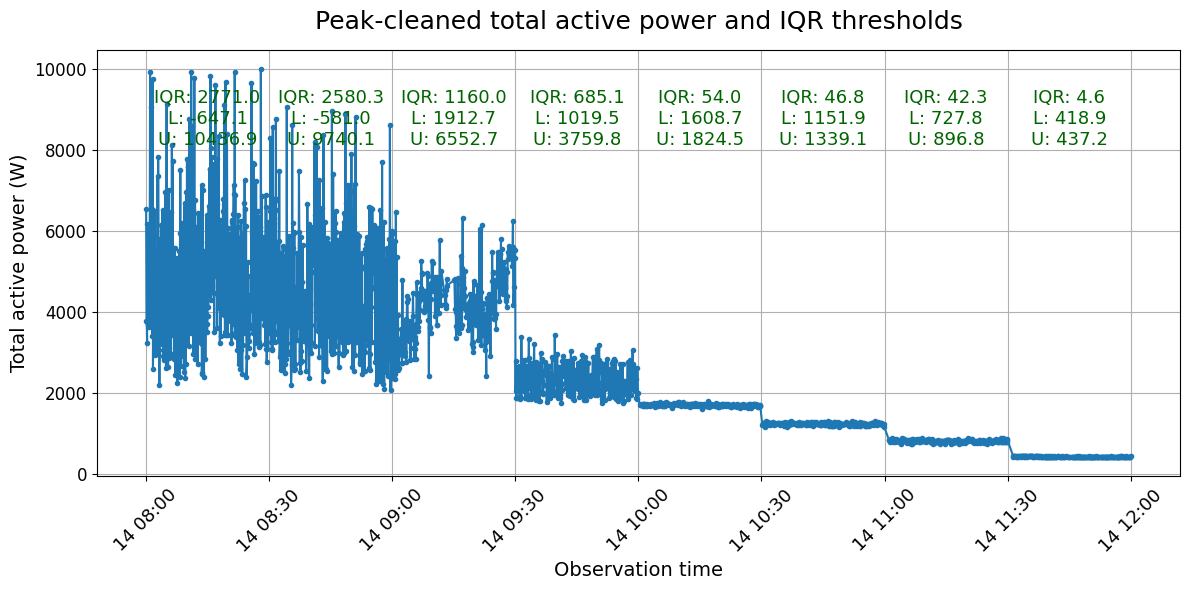

In [ ]:
start_time = pd.to_datetime('2025-07-14 08:00')
end_time = pd.to_datetime('2025-07-14 12:00')

cleaned_data = []
annotations = []

current_start = start_time

while current_start < end_time:
    current_end = current_start + pd.Timedelta(minutes=30)

    window_df = df[
        (df['OBSERVATION_TIME'] >= current_start) &
        (df['OBSERVATION_TIME'] < current_end)
    ]

    if not window_df.empty:
        Q1 = window_df['TOTAL_ACT_POWER'].quantile(0.25)
        Q3 = window_df['TOTAL_ACT_POWER'].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        filtered_window = window_df[
            (window_df['TOTAL_ACT_POWER'] >= lower_bound) &
            (window_df['TOTAL_ACT_POWER'] <= upper_bound)
        ]

        cleaned_data.append(filtered_window)

        midpoint = current_start + (current_end - current_start) / 2

        annotations.append({
            'time': midpoint,
            'iqr': IQR,
            'low': lower_bound,
            'high': upper_bound
        })

    current_start = current_end

cleaned_df = pd.concat(cleaned_data).sort_values('OBSERVATION_TIME')

plt.figure(figsize=(12, 6))

plt.plot(
    cleaned_df['OBSERVATION_TIME'],
    cleaned_df['TOTAL_ACT_POWER'],
    marker='o',
    linestyle='-',
    markersize=3
)

y_max = cleaned_df['TOTAL_ACT_POWER'].max()

for ann in annotations:
    text = f"IQR: {ann['iqr']:.1f}\nL: {ann['low']:.1f}\nU: {ann['high']:.1f}"

    plt.text(
        ann['time'],
        y_max * 0.95,
        text,
        ha='center',
        va='top',
        fontsize=13,
        rotation=0,
        color='darkgreen'
    )

plt.title('Peak-cleaned total active power and IQR thresholds', fontsize=18, pad=15)
plt.xlabel('Observation time', fontsize=14)
plt.ylabel('Total active power (W)', fontsize=14)

plt.xticks(rotation=45, fontsize=13)
plt.yticks(fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

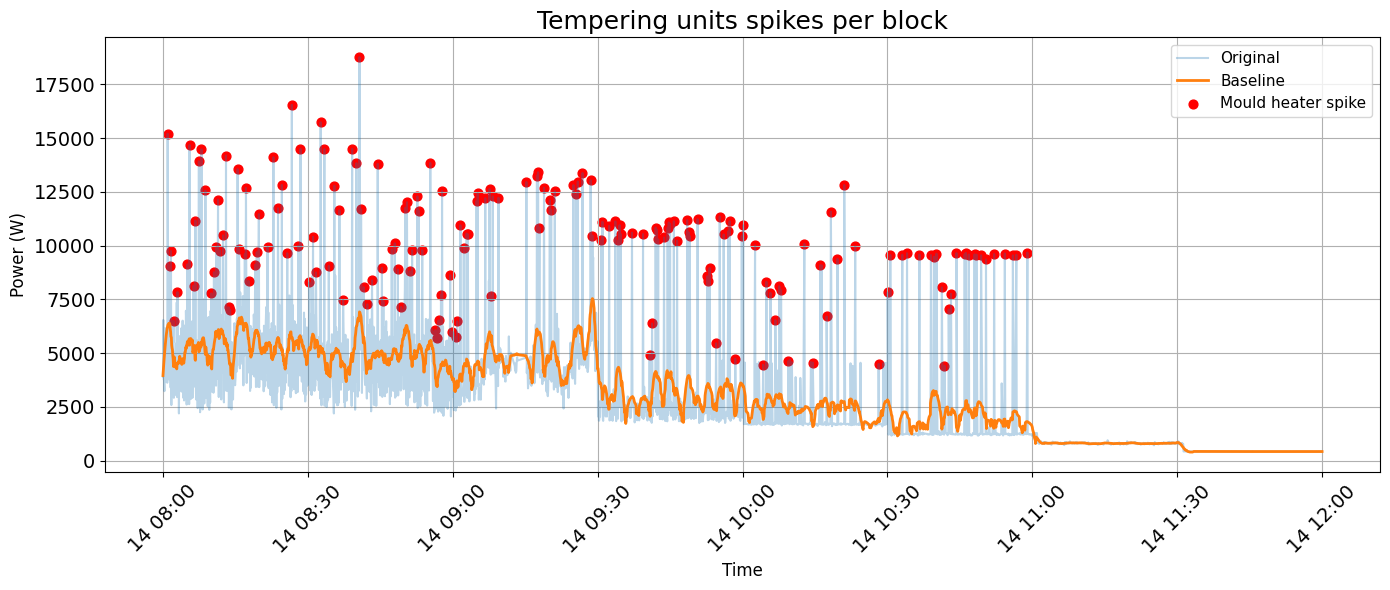

In [ ]:
df['SG'] = sg_smooth(df['TOTAL_ACT_POWER'], 33, 3)

df['residual'] = df['TOTAL_ACT_POWER'] - df['SG']

median = np.median(df['residual'])
mad = np.median(np.abs(df['residual'] - median))

threshold = median + 4 * mad

peaks, _ = find_peaks(
    df['residual'].values,
    height=threshold,
    distance=3,
    prominence=np.std(df['residual']) * 1.5
)

df['spike'] = False
df.loc[df.index[peaks], 'spike'] = True

spikes = df[df['spike']]

start_time = df['OBSERVATION_TIME'].min()
end_time   = df['OBSERVATION_TIME'].max()

annotations = []
current_start = start_time

while current_start < end_time:
    current_end = current_start + pd.Timedelta(minutes=10)

    block_spikes = spikes[
        (spikes['OBSERVATION_TIME'] >= current_start) &
        (spikes['OBSERVATION_TIME'] < current_end)
    ]

    midpoint = current_start + (current_end - current_start)/2

    annotations.append({
        "time": midpoint,
        "count": len(block_spikes),
        "start": current_start,
        "end": current_end
    })

    current_start = current_end

plt.figure(figsize=(14,6))

plt.plot(
    df['OBSERVATION_TIME'],
    df['TOTAL_ACT_POWER'],
    alpha=0.3,
    label='Original'
)

plt.plot(
    df['OBSERVATION_TIME'],
    df['SG'],
    linewidth=2,
    label='Baseline'
)

plt.scatter(
    spikes['OBSERVATION_TIME'],
    spikes['TOTAL_ACT_POWER'],
    s=40,
    label='Mould heater spike',
    color="red"
)


y_max = df['TOTAL_ACT_POWER'].max()

plt.xlabel("Time", fontsize=12)
plt.ylabel("Power (W)", fontsize=12)

plt.legend(fontsize=11)

plt.grid(True)


plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.title("Tempering units spikes per block", fontsize=18)

plt.tight_layout()
plt.show()

## Testing autoencoder

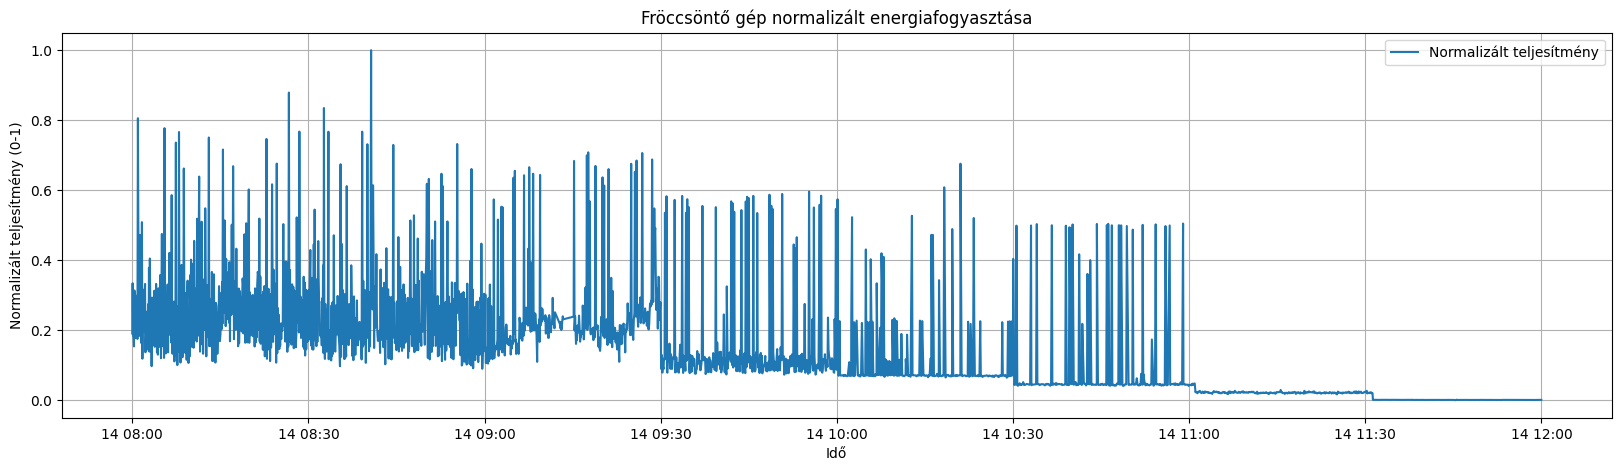

In [ ]:
power = df[['TOTAL_ACT_POWER']].values

scaler = MinMaxScaler()
power_scaled = scaler.fit_transform(power)


df['TOTAL_ACT_POWER_NORMALIZED'] = power_scaled


plt.figure(figsize=(20, 5))
plt.plot(pd.to_datetime(df['OBSERVATION_TIME']), df['TOTAL_ACT_POWER_NORMALIZED'], label='Normalizált teljesítmény')
plt.xlabel('Idő')
plt.ylabel('Normalizált teljesítmény (0-1)')
plt.title('Fröccsöntő gép normalizált energiafogyasztása')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_idle = df[['TOTAL_ACT_POWER_NORMALIZED']].values
X_idle_train = X_idle[:600]
X_idle_test = X_idle[600:720]

print("Training dataset:", X_idle_train.shape)
print("Test dataset:", X_idle_test.shape)

Training dataset: (600, 1)
Test dataset: (120, 1)


In [ ]:
input_dim = X_idle_train.shape[1]
input_layer = Input(shape=(input_dim,))

encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(4, activation='relu')(encoded)

decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_idle_train, X_idle_train,
    epochs=100,
    batch_size=8,
    shuffle=False,
    validation_split=0.1
)

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0660 - val_loss: 0.0503
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0382 - val_loss: 0.0196
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0220 - val_loss: 0.0109
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0180 - val_loss: 0.0087
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0149 - val_loss: 0.0070
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0114 - val_loss: 0.0052
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - val_loss: 0.0033
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 9/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017 - val_loss: 7.0986e-04
Epoch 10/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9207e-04 - val_loss: 3.2914e-04
Epoch 11/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.6466e-04 - val_loss: 1.9883e-04
Epoch 12/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 

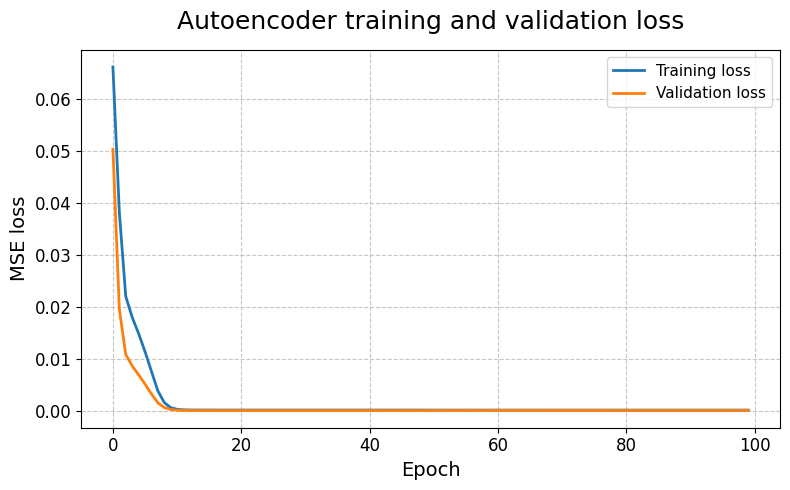

In [ ]:
plt.figure(figsize=(8, 5))


plt.plot(history.history['loss'], label='Training loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation loss', linewidth=2)


plt.title('Autoencoder training and validation loss', fontsize=18, pad=15)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('MSE loss', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Anomália threshold: 0.0018399622650138066


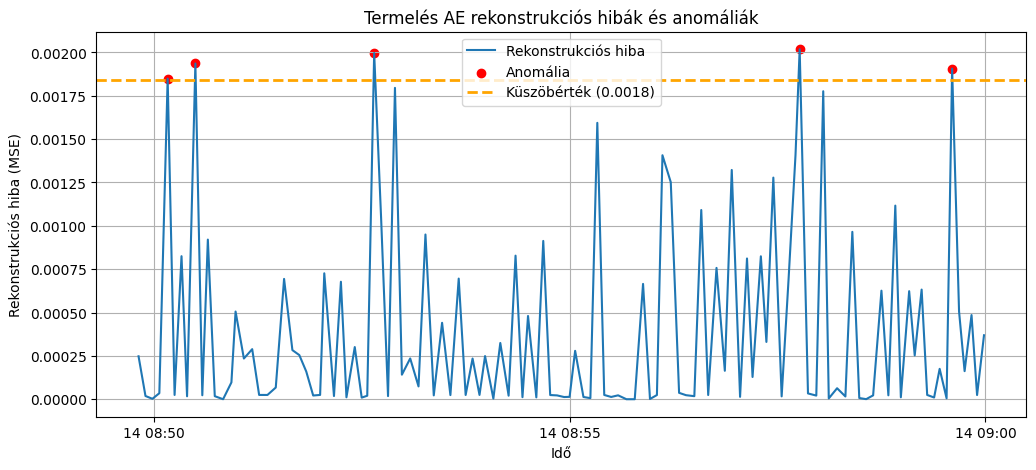

In [ ]:
X_pred_test = autoencoder.predict(X_idle_test)

mse_test = np.mean(np.power(X_idle_test - X_pred_test, 2), axis=1)

X_pred_train = autoencoder.predict(X_idle_train)
mse_train = np.mean(np.power(X_idle_train - X_pred_train, 2), axis=1)
threshold = np.percentile(mse_train, 99)
print("Anomália threshold:", threshold)

anomalies = mse_test > threshold

df_test = df.iloc[600:720].copy()
df_test['RECONSTRUCTION_ERROR'] = mse_test
df_test['ANOMALY'] = anomalies

df_test['ANOMALY_COUNT_30S'] = df_test.rolling(window='30s', on='OBSERVATION_TIME')['ANOMALY'].sum()
df_test['REAL_ALERT'] = df_test['ANOMALY_COUNT_30S'] >= 3
alert_times = df_test[df_test['REAL_ALERT']]['OBSERVATION_TIME']


plt.figure(figsize=(12,5))
plt.plot(df_test['OBSERVATION_TIME'], df_test['RECONSTRUCTION_ERROR'], label='Rekonstrukciós hiba')
plt.scatter(df_test['OBSERVATION_TIME'][anomalies],
            df_test['RECONSTRUCTION_ERROR'][anomalies],
            color='red', label='Anomália')

for i, t in enumerate(alert_times):
    plt.axvline(x=t, color='purple', alpha=0.3, linestyle='-',
                label='VALÓDI RIASZTÁS' if i == 0 else "")

plt.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label=f'Küszöbérték ({threshold:.4f})')
plt.xlabel('Idő')
plt.ylabel('Rekonstrukciós hiba (MSE)')
plt.title('Termelés AE rekonstrukciós hibák és anomáliák')
plt.legend()
plt.grid(True)
plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Anomaly threshold: 0.0018399622650138066


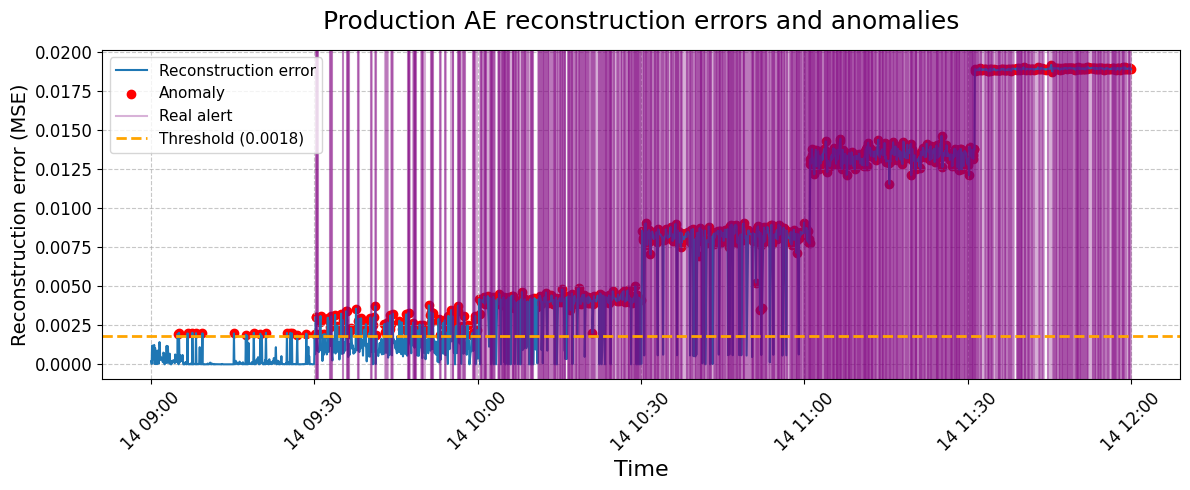

In [ ]:
df_test = df.iloc[720:].copy()
X_idle = df[['TOTAL_ACT_POWER_NORMALIZED']].values
X_idle_test = X_idle[720:]

# Predikciók és MSE hiba kiszámítása a teszt adatokon
X_pred_test = autoencoder.predict(X_idle_test)
mse_test = np.mean(np.power(X_idle_test - X_pred_test, 2), axis=1)

# Predikciók és küszöbérték (threshold) kiszámítása a tanító adatokon
X_pred_train = autoencoder.predict(X_idle_train)
mse_train = np.mean(np.power(X_idle_train - X_pred_train, 2), axis=1)
threshold = np.percentile(mse_train, 99)
print("Anomaly threshold:", threshold) # Fordítva

anomalies = mse_test > threshold

df_test['RECONSTRUCTION_ERROR'] = mse_test
df_test['ANOMALY'] = anomalies

df_test['ANOMALY_COUNT_30S'] = df_test.rolling(window='30s', on='OBSERVATION_TIME')['ANOMALY'].sum()
df_test['REAL_ALERT'] = df_test['ANOMALY_COUNT_30S'] >= 3
alert_times = df_test[df_test['REAL_ALERT']]['OBSERVATION_TIME']


plt.figure(figsize=(12, 5))

plt.plot(df_test['OBSERVATION_TIME'], df_test['RECONSTRUCTION_ERROR'], label='Reconstruction error')

plt.scatter(df_test['OBSERVATION_TIME'][anomalies],
            df_test['RECONSTRUCTION_ERROR'][anomalies],
            color='red', label='Anomaly')

for i, t in enumerate(alert_times):
    plt.axvline(x=t, color='purple', alpha=0.3, linestyle='-',
                label='Real alert' if i == 0 else "")

plt.axhline(y=threshold, color='orange', linestyle='--', linewidth=2,
            label=f'Threshold ({threshold:.4f})')


plt.title('Production AE reconstruction errors and anomalies', fontsize=18, pad=15)
plt.xlabel('Time', fontsize=16)
plt.ylabel('Reconstruction error (MSE)', fontsize=14)

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Define monitoring system

In [ ]:
def calculate_consumption(power_samples, sample_time_sec=5):
    total_energy_joule = np.sum(np.array(power_samples) * sample_time_sec)
    total_energy_kwh = total_energy_joule / 3_600_000
    return total_energy_joule, total_energy_kwh

def monitoring_system(df):
    df['PRODUCTION_STATUS'] = pd.to_numeric(df['PRODUCTION_STATUS'], errors='coerce').ffill()
    df['PRODUCTIONSTATUS_NAME'] = df['PRODUCTIONSTATUS_NAME'].ffill()
    df['PRODNAME'] = df['PRODNAME'].ffill()

    status_name_mapping = df.dropna(subset=['PRODUCTION_STATUS', 'PRODUCTIONSTATUS_NAME'])\
                            .set_index('PRODUCTION_STATUS')['PRODUCTIONSTATUS_NAME'].to_dict()

    status_translations = {
        '14_Termelés': '14_Production',
        '01_Gyártás előkészítés': '01_Production preparation',
        '01_Gyártás elokészítés': '01_Production preparation',
        '00_Nincs termelés': '00_No production',
        #'13_QEP Kék láda': 'Enhanced quality control',
        '16_Technológiai próba': '16_Technological trial'
    }

    predefined_colors = {
        2: 'green',         # 14_Termelés
        3: 'gray',          # 01_Gyártás előkészítés
        4: 'red',           # 00_Nincs termelés
        #6: 'lightgray',     # 13_QEP Kék láda
        14: 'lightblue'     # 16_Technológiai próba
    }

    statuses = df['PRODUCTION_STATUS'].dropna().unique()
    status_colors = {status: predefined_colors.get(status, 'cyan') for status in statuses}

    df['SG'] = sg_smooth(df['TOTAL_ACT_POWER'], 33, 3)
    df['residual'] = df['TOTAL_ACT_POWER'] - df['SG']
    median = np.median(df['residual'])
    mad = np.median(np.abs(df['residual'] - median))
    threshold = median + 4 * mad

    peaks, _ = find_peaks(
        df['residual'].values,
        height=threshold,
        distance=2,
        prominence=np.std(df['residual']) * 1.5
    )

    df['spike'] = False
    df.loc[df.index[peaks], 'spike'] = True

    df['waste_spike'] = False
    df['ACTUALQUANTITY_PLOT'] = df['ACTUALQUANTITY'].ffill().fillna(0)

    waste_log = []
    block_minutes = 60
    current_start = df['OBSERVATION_TIME'].min()
    total_end = df['OBSERVATION_TIME'].max()

    while current_start < total_end:
        current_end = current_start + pd.Timedelta(minutes=block_minutes)
        mask = (df['OBSERVATION_TIME'] >= current_start) & (df['OBSERVATION_TIME'] < current_end)
        block_data = df[mask].copy()

        if not block_data.empty:
            waste_spike_count = block_data[(block_data['spike'] == True) & (block_data['PRODUCTION_STATUS'] == 4)].shape[0]
            is_no_production_at_end = block_data['PRODUCTION_STATUS'].iloc[-1] == 4

            if is_no_production_at_end and waste_spike_count >= 3:
                waste_indices = block_data[(block_data['spike'] == True) & (block_data['PRODUCTION_STATUS'] == 4)].index
                df.loc[waste_indices, 'waste_spike'] = True

                no_prod_data = block_data[block_data['PRODUCTION_STATUS'] == 4]

                duration_hrs = (no_prod_data['OBSERVATION_TIME'].max() - no_prod_data['OBSERVATION_TIME'].min()).total_seconds() / 3600

                total_waste_joule, _ = calculate_consumption(no_prod_data['TOTAL_ACT_POWER'], sample_time_sec=5)

                energy_wh = total_waste_joule / 3600

                avg_power_w = no_prod_data['TOTAL_ACT_POWER'].mean()

                waste_log.append({
                    'Start of period': current_start,
                    'End of period': current_end,
                    'Wasteful consumption point': waste_spike_count,
                    'Average AC power (W)': round(avg_power_w, 0),
                    'Duration (hours)': round(duration_hrs, 2),
                    'Unnecessary energy (Wh)': round(energy_wh, 2)
                })
        current_start = current_end

    waste_df = pd.DataFrame(waste_log)
    if not waste_df.empty:
        print("\n--- UNNECESSARY ENERGY CONSUMPTION REPORT ---")
        no_prod_data.to_csv('no_prod_data.csv', index=False, encoding='utf-8')
        print(waste_df.to_string(index=False))

        total_waste_kwh = waste_df['Unnecessary energy (Wh)'].sum() / 1000
        total_waste_hours = waste_df['Duration (hours)'].sum()

        print("\n" + "="*50)
        print("            SUMMARY")
        print("="*50)
        print(f"Total time of wasteful consumption : {total_waste_hours:.2f} hours")
        print(f"Total wasted energy                : {total_waste_kwh:.2f} kWh")
        print("="*50)
    else:
        print("\nNo wasteful consumption was found based on the specified criteria.")


    fig, ax1 = plt.subplots(figsize=(14,6))
    ymin, ymax = 0, df['TOTAL_ACT_POWER'].max() * 1.1
    ax1.set_ylim(ymin, ymax)

    prev_status = None
    segment_start = df['OBSERVATION_TIME'].iloc[0]
    prod_name = None

    for i, row in df.iterrows():
        current_status = row['PRODUCTION_STATUS']

        if pd.isna(current_status):
            continue

        if prev_status is None:
            prev_status = current_status
            segment_start = row['OBSERVATION_TIME']
            prod_name = row['PRODNAME']
            continue

        if current_status != prev_status or i == df.index[-1]:
            ax1.axvspan(segment_start, row['OBSERVATION_TIME'], color=status_colors.get(prev_status, 'cyan'), alpha=0.2)

            if prev_status == 2 and pd.notna(prod_name):
                mid_time = segment_start + (row['OBSERVATION_TIME'] - segment_start) / 2
                ax1.text(
                    mid_time,
                    ymax * 0.9,
                    str(prod_name),
                    ha='center',
                    va='top',
                    rotation=90,
                    fontsize=10,
                    alpha=0.8
                )

            segment_start = row['OBSERVATION_TIME']
            prev_status = current_status
            prod_name = row['PRODNAME']

    ax1.plot(df['OBSERVATION_TIME'], df['TOTAL_ACT_POWER'], alpha=0.3, label='Original Power', color='tab:blue')
    ax1.plot(df['OBSERVATION_TIME'], df['SG'], linewidth=2, label='Baseline (SG)', color='tab:orange')

    normal_spikes = df[(df['spike'] == True) & (df['waste_spike'] == False)]
    wasteful_spikes = df[df['waste_spike'] == True]

    ax1.scatter(normal_spikes['OBSERVATION_TIME'], normal_spikes['TOTAL_ACT_POWER'], s=40, label='Normal spike', color='red', zorder=5)
    ax1.scatter(wasteful_spikes['OBSERVATION_TIME'], wasteful_spikes['TOTAL_ACT_POWER'], s=40, label='Wasteful spike', color='black', zorder=6)

    ax1.set_ylabel('Active power (W)', fontsize=12)
    ax1.set_xlabel('Time', fontsize=12)

    ax2 = ax1.twinx()
    ax2.step(df['OBSERVATION_TIME'], df['ACTUALQUANTITY_PLOT'], where='post', color='black', linewidth=1.5, label='Cumulative quantity', linestyle='--')
    ax2.set_ylabel('Cumulative quantity (pcs)', fontsize=12)

    status_patches = []
    for status, color in status_colors.items():
        original_name = status_name_mapping.get(status, f"Status Code: {status}")
        english_name = status_translations.get(original_name, original_name)
        status_patches.append(mpatches.Patch(color=color, label=english_name))

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles=h1 + h2 + status_patches,
        bbox_to_anchor=(1.1, 1),
        loc='upper left',
        borderaxespad=0.,
        fontsize=12
    )

    ax1.grid(True)
    ax1.tick_params(axis='x', rotation=45, labelsize=10)
    ax1.tick_params(axis='y', labelsize=10)
    ax1.set_title("Energy monitoring: spikes and production state synchronized", fontsize=18)

    plt.tight_layout()
    plt.show()



    spikes_only = df[df['spike'] == True].copy()

    df_10m = spikes_only.set_index('OBSERVATION_TIME').resample('1min').agg({
        'TOTAL_ACT_POWER': 'mean',
        'waste_spike': 'any'
    }).dropna().reset_index()

    bar_colors = ['red' if is_waste else 'green' for is_waste in df_10m['waste_spike']]

    fig2, ax_bar = plt.subplots(figsize=(14, 6))

    ymax_bar = df_10m['TOTAL_ACT_POWER'].max() * 1.2
    if pd.isna(ymax_bar) or ymax_bar == 0:
        ymax_bar = 1000
    ax_bar.set_ylim(0, ymax_bar)

    prev_status = None
    segment_start = df['OBSERVATION_TIME'].iloc[0]
    prod_name = None

    for i, row in df.iterrows():
        current_status = row['PRODUCTION_STATUS']

        if pd.isna(current_status):
            continue

        if prev_status is None:
            prev_status = current_status
            segment_start = row['OBSERVATION_TIME']
            prod_name = row['PRODNAME']
            continue

        if current_status != prev_status or i == df.index[-1]:
            ax_bar.axvspan(segment_start, row['OBSERVATION_TIME'], color=status_colors.get(prev_status, 'cyan'), alpha=0.2, zorder=1)

            if prev_status == 2 and pd.notna(prod_name):
                mid_time = segment_start + (row['OBSERVATION_TIME'] - segment_start) / 2
                ax_bar.text(
                    mid_time,
                    ymax_bar * 0.95,
                    str(prod_name),
                    ha='center',
                    va='top',
                    rotation=90,
                    fontsize=10,
                    alpha=0.8,
                    zorder=4
                )

            segment_start = row['OBSERVATION_TIME']
            prev_status = current_status
            prod_name = row['PRODNAME']

    ax_bar.bar(df_10m['OBSERVATION_TIME'], df_10m['TOTAL_ACT_POWER'], width=pd.Timedelta(minutes=8), color=bar_colors, align='center', zorder=3)


    ax_bar.set_ylabel('Active power of consumption (W)', fontsize=14)
    ax_bar.set_xlabel('Time', fontsize=14)

    ax_bar.set_title('Good vs. unnecessary consumption spikes', fontsize=18, pad=55)

    legend_elements = [
        mpatches.Patch(facecolor='green', label='Good consumption'),
        mpatches.Patch(facecolor='red', label='Unnecessary consumption')
    ]


    ax_bar.legend(
        handles=legend_elements + status_patches,
        bbox_to_anchor=(0.5, 1.02),
        loc='lower center',
        ncol=4,
        borderaxespad=0.,
        fontsize=11
    )

    ax_bar.grid(axis='y', linestyle='--', alpha=0.7, zorder=2)
    ax_bar.tick_params(axis='x', rotation=45, labelsize=12)
    ax_bar.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    plt.show()

    fig3, ax_timeline = plt.subplots(figsize=(14, 4.5))


    top_bar_colors = {
        2: 'green',         # 14_Termelés
        4: 'gray',          # 00_Nincs termelés
        3: 'orange',        # 01_Gyártás előkészítés
        #6: 'cyan',          # 13_QEP Kék láda
        14: 'purple'        # 16_Technológiai próba (biztonság kedvéért)
    }


    prev_status = None
    segment_start = df['OBSERVATION_TIME'].iloc[0]

    for i, row in df.iterrows():
        current_status = row['PRODUCTION_STATUS']

        if pd.isna(current_status):
            continue

        if prev_status is None:
            prev_status = current_status
            segment_start = row['OBSERVATION_TIME']
            continue

        if current_status != prev_status or i == df.index[-1]:
            color = top_bar_colors.get(prev_status, 'white')

            ax_timeline.fill_between([segment_start, row['OBSERVATION_TIME']], 2.1, 2.9, color=color, alpha=0.8)

            segment_start = row['OBSERVATION_TIME']
            prev_status = current_status


    ax_timeline.fill_between(
        df['OBSERVATION_TIME'], 0.1, 0.9,
        where=(df['spike'] == False),
        color='lightyellow', step='mid', alpha=0.9
    )


    ax_timeline.fill_between(
        df['OBSERVATION_TIME'], 0.1, 0.9,
        where=(df['spike'] == True) & (df['waste_spike'] == False),
        color='blue', step='mid', alpha=0.9
    )

    ax_timeline.fill_between(
        df['OBSERVATION_TIME'], 0.1, 0.9,
        where=(df['waste_spike'] == True),
        color='black', step='mid', alpha=0.9
    )


    ax_timeline.set_ylim(-0.2, 3.8)

    ax_timeline.set_yticks([0.5, 2.5])
    ax_timeline.set_yticklabels(['Consumption state\n(Blue=Good, Black=Waste,\nYellow=None)', 'Production state\n(MES statuses)'], fontsize=12)

    ax_timeline.set_title("Timeline of production and energy consumption 2026. 02.", fontsize=18, pad=75)
    ax_timeline.set_xlabel('Time', fontsize=14)

    legend_elements_timeline = [
        mpatches.Patch(facecolor='green', alpha=0.8, label='Production'),
        mpatches.Patch(facecolor='orange', alpha=0.8, label='Machine setting'),
        #mpatches.Patch(facecolor='cyan', alpha=0.8, label='Enhanced quality control'),
        mpatches.Patch(facecolor='gray', alpha=0.8, label='No production'),
        mpatches.Patch(facecolor='blue', alpha=0.9, label='Useful consumption'),
        mpatches.Patch(facecolor='black', alpha=0.9, label='Wasted consumption'),
        mpatches.Patch(facecolor='lightyellow', edgecolor='gray', linewidth=1, label='No consumption')
    ]

    ax_timeline.legend(
        handles=legend_elements_timeline,
        bbox_to_anchor=(0.5, 1.05),
        loc='lower center',
        ncol=4,
        borderaxespad=0.,
        fontsize=11
    )

    ax_timeline.grid(axis='x', linestyle='--', alpha=0.7)
    ax_timeline.tick_params(axis='x', rotation=45, labelsize=12)

    plt.tight_layout()
    plt.show()

## Testing monitoring system on real-word dataset - 2026.02

In [ ]:
file_path = "/content/feb_production.csv"


--- UNNECESSARY ENERGY CONSUMPTION REPORT ---
    Start of period       End of period  Wasteful consumption point  Average AC power (W)  Duration (hours)  Unnecessary energy (Wh)
2026-02-01 07:59:54 2026-02-01 08:59:54                          22           4054.000000          1.000000              2421.010000
2026-02-01 08:59:54 2026-02-01 09:59:54                          26           5751.000000          1.000000              5599.720000
2026-02-05 18:59:54 2026-02-05 19:59:54                           3           1379.000000          0.960000               505.660000
2026-02-05 20:59:54 2026-02-05 21:59:54                          33           3967.000000          0.600000              1713.420000
2026-02-05 21:59:54 2026-02-05 22:59:54                          22           3009.000000          1.000000              2177.580000
2026-02-05 22:59:54 2026-02-05 23:59:54                           4           2905.000000          1.000000              2238.930000
2026-02-05 23:59:54 20

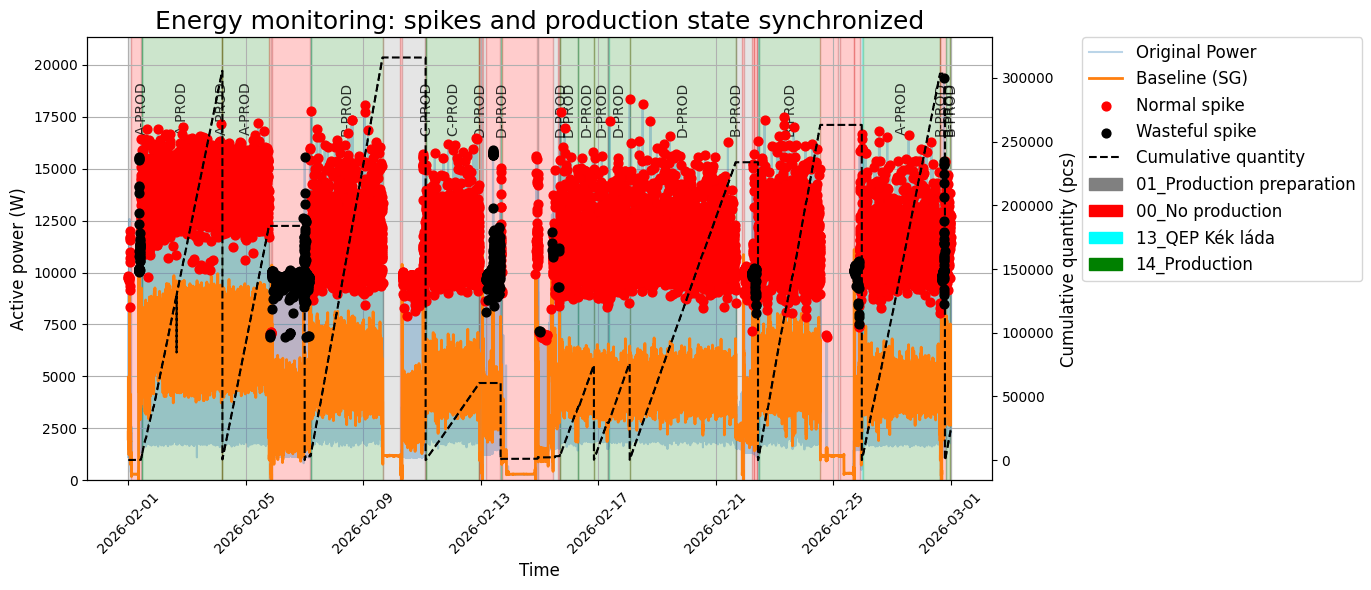

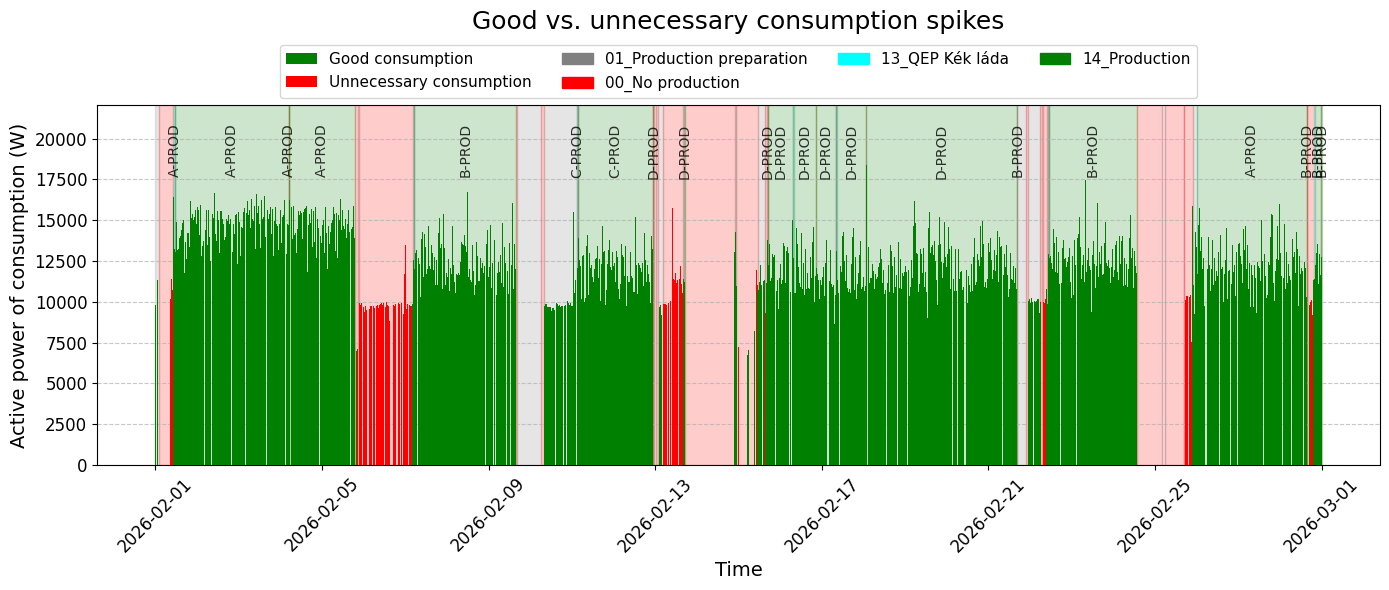

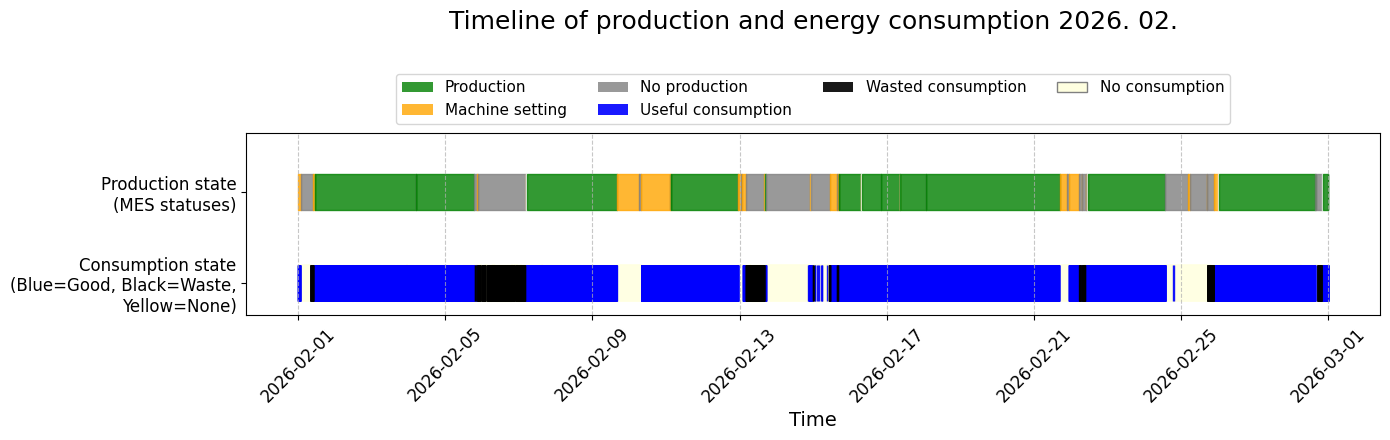

In [ ]:
df = pd.read_csv(file_path, low_memory=False)
df = df[df['DEVICE_ID'] == 'shellypro3em-a0dd6c9f5048'].copy()
df['OBSERVATION_TIME'] = pd.to_datetime(df['OBSERVATION_TIME'])
df = df.sort_values('OBSERVATION_TIME')
#df = df[df['OBSERVATION_TIME'].between('2026-02-05 23:00', '2026-02-06 00:00')].copy()
monitoring_system(df)

## Testing monitoring system on real-word dataset 2026.03


In [ ]:
file_path = "/content/mar_production.csv"


--- UNNECESSARY ENERGY CONSUMPTION REPORT ---
    Start of period       End of period  Wasteful consumption point  Average AC power (W)  Duration (hours)  Unnecessary energy (Wh)
2026-03-03 23:59:54 2026-03-04 00:59:54                           4           2693.000000          0.400000               785.420000
2026-03-04 00:59:54 2026-03-04 01:59:54                          15           2762.000000          1.000000              2152.250000
2026-03-04 01:59:54 2026-03-04 02:59:54                          12           2809.000000          1.000000              2172.720000
2026-03-04 02:59:54 2026-03-04 03:59:54                          23           2808.000000          1.000000              2176.290000
2026-03-04 03:59:54 2026-03-04 04:59:54                          29           3004.000000          1.000000              2236.620000
2026-03-04 04:59:54 2026-03-04 05:59:54                          34           3021.000000          1.000000              2291.210000
2026-03-04 05:59:54 20

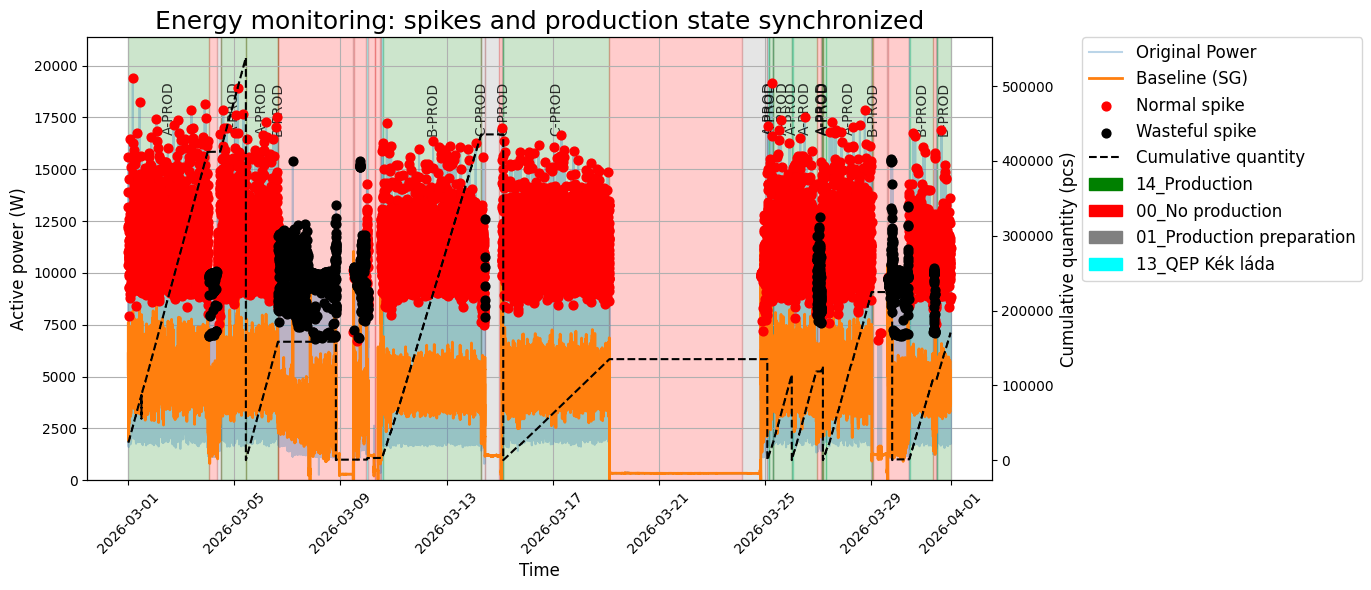

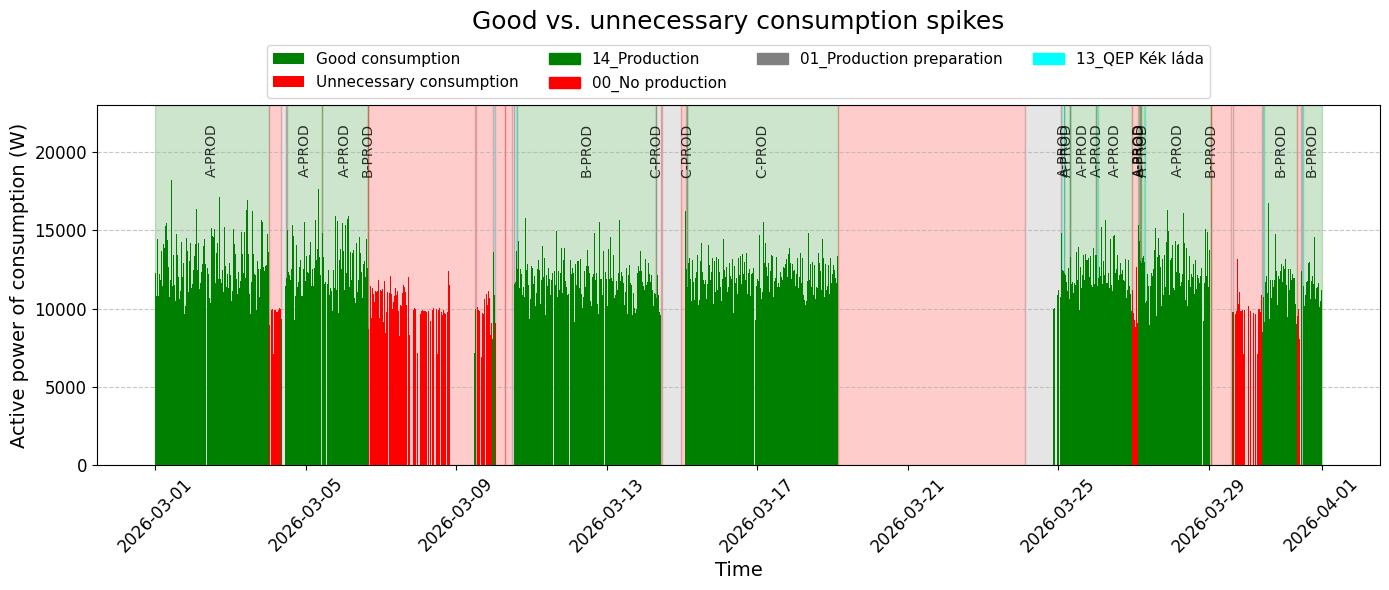

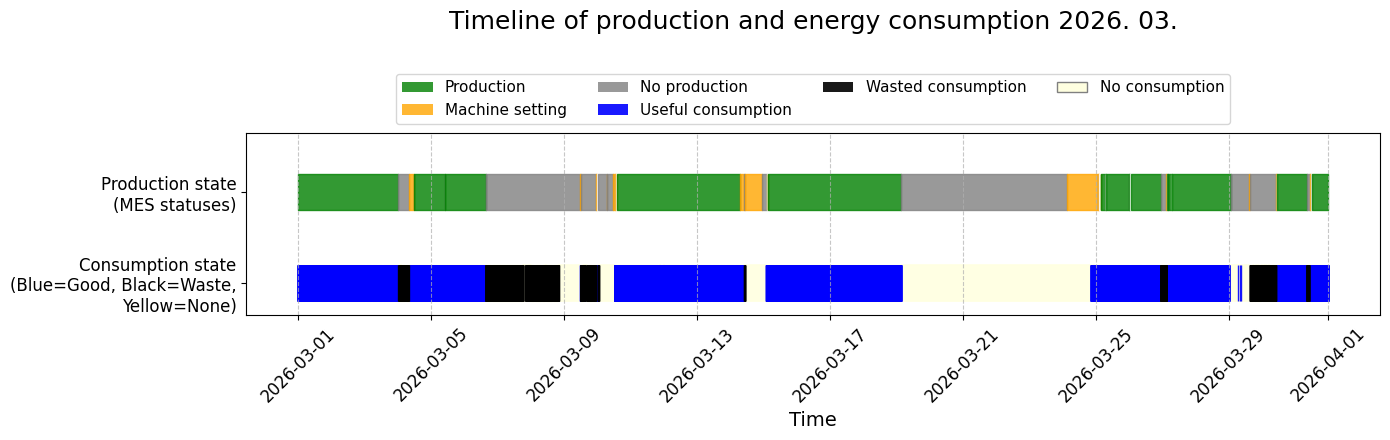

In [ ]:
df = pd.read_csv(file_path, low_memory=False)
df = df[df['DEVICE_ID'] == 'shellypro3em-a0dd6c9f5048'].copy()
df['OBSERVATION_TIME'] = pd.to_datetime(df['OBSERVATION_TIME'])
df = df.sort_values('OBSERVATION_TIME')
monitoring_system(df)

In [ ]:
def calculate_consumption(power_samples, sample_time_sec=5):
    total_energy_joule = np.sum(np.array(power_samples) * sample_time_sec)
    total_energy_kwh = total_energy_joule / 3_600_000
    return total_energy_joule, total_energy_kwh

def monitoring_system(df):
    df['PRODUCTION_STATUS'] = pd.to_numeric(df['PRODUCTION_STATUS'], errors='coerce').ffill()
    df['PRODUCTIONSTATUS_NAME'] = df['PRODUCTIONSTATUS_NAME'].ffill()
    df['PRODNAME'] = df['PRODNAME'].ffill()

    status_name_mapping = df.dropna(subset=['PRODUCTION_STATUS', 'PRODUCTIONSTATUS_NAME'])\
                            .set_index('PRODUCTION_STATUS')['PRODUCTIONSTATUS_NAME'].to_dict()

    status_translations = {
        '14_Termelés': '14_Production',
        '01_Gyártás előkészítés': '01_Production preparation',
        '01_Gyártás elokészítés': '01_Production preparation',
        '00_Nincs termelés': '00_No production',
        #'13_QEP Kék láda': 'Enhanced quality control',
        '16_Technológiai próba': '16_Technological trial'
    }

    predefined_colors = {
        2: 'green',         # 14_Termelés
        3: 'gray',          # 01_Gyártás előkészítés
        4: 'red',           # 00_Nincs termelés
        #6: 'lightgray',     # 13_QEP Kék láda
        14: 'lightblue'     # 16_Technológiai próba
    }

    statuses = df['PRODUCTION_STATUS'].dropna().unique()
    status_colors = {status: predefined_colors.get(status, 'cyan') for status in statuses}

    df['SG'] = sg_smooth(df['TOTAL_ACT_POWER'], 33, 3)
    df['residual'] = df['TOTAL_ACT_POWER'] - df['SG']
    median = np.median(df['residual'])
    mad = np.median(np.abs(df['residual'] - median))
    threshold = median + 4 * mad

    peaks, _ = find_peaks(
        df['residual'].values,
        height=threshold,
        distance=2,
        prominence=np.std(df['residual']) * 1.5
    )

    df['spike'] = False
    df.loc[df.index[peaks], 'spike'] = True

    df['waste_spike'] = False
    df['ACTUALQUANTITY_PLOT'] = df['ACTUALQUANTITY'].ffill().fillna(0)

    waste_log = []
    block_minutes = 60
    current_start = df['OBSERVATION_TIME'].min()
    total_end = df['OBSERVATION_TIME'].max()

    while current_start < total_end:
        current_end = current_start + pd.Timedelta(minutes=block_minutes)
        mask = (df['OBSERVATION_TIME'] >= current_start) & (df['OBSERVATION_TIME'] < current_end)
        block_data = df[mask].copy()

        if not block_data.empty:
            waste_spike_count = block_data[(block_data['spike'] == True) & (block_data['PRODUCTION_STATUS'] == 4)].shape[0]
            is_no_production_at_end = block_data['PRODUCTION_STATUS'].iloc[-1] == 4

            if is_no_production_at_end and waste_spike_count >= 3:
                waste_indices = block_data[(block_data['spike'] == True) & (block_data['PRODUCTION_STATUS'] == 4)].index
                df.loc[waste_indices, 'waste_spike'] = True

                no_prod_data = block_data[block_data['PRODUCTION_STATUS'] == 4]

                duration_hrs = (no_prod_data['OBSERVATION_TIME'].max() - no_prod_data['OBSERVATION_TIME'].min()).total_seconds() / 3600

                total_waste_joule, _ = calculate_consumption(no_prod_data['TOTAL_ACT_POWER'], sample_time_sec=5)

                energy_wh = total_waste_joule / 3600

                avg_power_w = no_prod_data['TOTAL_ACT_POWER'].mean()

                waste_log.append({
                    'Start of period': current_start,
                    'End of period': current_end,
                    'Wasteful consumption point': waste_spike_count,
                    'Average AC power (W)': round(avg_power_w, 0),
                    'Duration (hours)': round(duration_hrs, 2),
                    'Unnecessary energy (Wh)': round(energy_wh, 2)
                })
        current_start = current_end

    waste_df = pd.DataFrame(waste_log)
    if not waste_df.empty:
        print("\n--- UNNECESSARY ENERGY CONSUMPTION REPORT ---")
        print(no_prod_data)
        no_prod_data.to_csv('no_prod_data.csv', index=False, encoding='utf-8')
        '''print(waste_df.to_string(index=False))

        total_waste_kwh = waste_df['Unnecessary energy (Wh)'].sum() / 1000
        total_waste_hours = waste_df['Duration (hours)'].sum()

        print("\n" + "="*50)
        print("            SUMMARY")
        print("="*50)
        print(f"Total time of wasteful consumption : {total_waste_hours:.2f} hours")
        print(f"Total wasted energy                : {total_waste_kwh:.2f} kWh")
        print("="*50)
        '''
    else:
        print("\nNo wasteful consumption was found based on the specified criteria.")


    fig, ax1 = plt.subplots(figsize=(14,6))
    ymin, ymax = 0, df['TOTAL_ACT_POWER'].max() * 1.1
    ax1.set_ylim(ymin, ymax)

    prev_status = None
    segment_start = df['OBSERVATION_TIME'].iloc[0]
    prod_name = None

    for i, row in df.iterrows():
        current_status = row['PRODUCTION_STATUS']

        if pd.isna(current_status):
            continue

        if prev_status is None:
            prev_status = current_status
            segment_start = row['OBSERVATION_TIME']
            prod_name = row['PRODNAME']
            continue

        if current_status != prev_status or i == df.index[-1]:
            ax1.axvspan(segment_start, row['OBSERVATION_TIME'], color=status_colors.get(prev_status, 'cyan'), alpha=0.2)

            if prev_status == 2 and pd.notna(prod_name):
                mid_time = segment_start + (row['OBSERVATION_TIME'] - segment_start) / 2
                ax1.text(
                    mid_time,
                    ymax * 0.9,
                    str(prod_name),
                    ha='center',
                    va='top',
                    rotation=90,
                    fontsize=10,
                    alpha=0.8
                )

            segment_start = row['OBSERVATION_TIME']
            prev_status = current_status
            prod_name = row['PRODNAME']

    ax1.plot(df['OBSERVATION_TIME'], df['TOTAL_ACT_POWER'], alpha=0.3, label='Original Power', color='tab:blue')
    ax1.plot(df['OBSERVATION_TIME'], df['SG'], linewidth=2, label='Baseline (SG)', color='tab:orange')

    normal_spikes = df[(df['spike'] == True) & (df['waste_spike'] == False)]
    wasteful_spikes = df[df['waste_spike'] == True]

    ax1.scatter(normal_spikes['OBSERVATION_TIME'], normal_spikes['TOTAL_ACT_POWER'], s=40, label='Normal spike', color='red', zorder=5)
    ax1.scatter(wasteful_spikes['OBSERVATION_TIME'], wasteful_spikes['TOTAL_ACT_POWER'], s=40, label='Wasteful spike', color='black', zorder=6)

    ax1.set_ylabel('Active power (W)', fontsize=12)
    ax1.set_xlabel('Time', fontsize=12)

    ax2 = ax1.twinx()
    ax2.step(df['OBSERVATION_TIME'], df['ACTUALQUANTITY_PLOT'], where='post', color='black', linewidth=1.5, label='Cumulative quantity', linestyle='--')
    ax2.set_ylabel('Cumulative quantity (pcs)', fontsize=12)

    status_patches = []
    for status, color in status_colors.items():
        original_name = status_name_mapping.get(status, f"Status Code: {status}")
        english_name = status_translations.get(original_name, original_name)
        status_patches.append(mpatches.Patch(color=color, label=english_name))

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles=h1 + h2 + status_patches,
        bbox_to_anchor=(1.1, 1),
        loc='upper left',
        borderaxespad=0.,
        fontsize=12
    )

    ax1.grid(True)
    ax1.tick_params(axis='x', rotation=45, labelsize=10)
    ax1.tick_params(axis='y', labelsize=10)
    ax1.set_title("Energy monitoring: spikes and production state synchronized", fontsize=18)

    plt.tight_layout()
    plt.show()



    spikes_only = df[df['spike'] == True].copy()

    df_10m = spikes_only.set_index('OBSERVATION_TIME').resample('1min').agg({
        'TOTAL_ACT_POWER': 'mean',
        'waste_spike': 'any'
    }).dropna().reset_index()

    bar_colors = ['red' if is_waste else 'green' for is_waste in df_10m['waste_spike']]

    fig2, ax_bar = plt.subplots(figsize=(14, 6))

    ymax_bar = df_10m['TOTAL_ACT_POWER'].max() * 1.2
    if pd.isna(ymax_bar) or ymax_bar == 0:
        ymax_bar = 1000
    ax_bar.set_ylim(0, ymax_bar)

    prev_status = None
    segment_start = df['OBSERVATION_TIME'].iloc[0]
    prod_name = None

    for i, row in df.iterrows():
        current_status = row['PRODUCTION_STATUS']

        if pd.isna(current_status):
            continue

        if prev_status is None:
            prev_status = current_status
            segment_start = row['OBSERVATION_TIME']
            prod_name = row['PRODNAME']
            continue

        if current_status != prev_status or i == df.index[-1]:
            ax_bar.axvspan(segment_start, row['OBSERVATION_TIME'], color=status_colors.get(prev_status, 'cyan'), alpha=0.2, zorder=1)

            if prev_status == 2 and pd.notna(prod_name):
                mid_time = segment_start + (row['OBSERVATION_TIME'] - segment_start) / 2
                ax_bar.text(
                    mid_time,
                    ymax_bar * 0.95,
                    str(prod_name),
                    ha='center',
                    va='top',
                    rotation=90,
                    fontsize=10,
                    alpha=0.8,
                    zorder=4
                )

            segment_start = row['OBSERVATION_TIME']
            prev_status = current_status
            prod_name = row['PRODNAME']

    ax_bar.bar(df_10m['OBSERVATION_TIME'], df_10m['TOTAL_ACT_POWER'], width=pd.Timedelta(minutes=8), color=bar_colors, align='center', zorder=3)


    ax_bar.set_ylabel('Active power of consumption (W)', fontsize=14)
    ax_bar.set_xlabel('Time', fontsize=14)

    ax_bar.set_title('Good vs. unnecessary consumption spikes', fontsize=18, pad=55)

    legend_elements = [
        mpatches.Patch(facecolor='green', label='Good consumption'),
        mpatches.Patch(facecolor='red', label='Unnecessary consumption')
    ]


    ax_bar.legend(
        handles=legend_elements + status_patches,
        bbox_to_anchor=(0.5, 1.02),
        loc='lower center',
        ncol=4,
        borderaxespad=0.,
        fontsize=11
    )

    ax_bar.grid(axis='y', linestyle='--', alpha=0.7, zorder=2)
    ax_bar.tick_params(axis='x', rotation=45, labelsize=12)
    ax_bar.tick_params(axis='y', labelsize=12)

    plt.tight_layout()
    plt.show()

    fig3, ax_timeline = plt.subplots(figsize=(14, 4.5))


    top_bar_colors = {
        2: 'green',         # 14_Termelés
        4: 'gray',          # 00_Nincs termelés
        3: 'orange',        # 01_Gyártás előkészítés
        #6: 'cyan',          # 13_QEP Kék láda
        14: 'purple'        # 16_Technológiai próba (biztonság kedvéért)
    }


    prev_status = None
    segment_start = df['OBSERVATION_TIME'].iloc[0]

    for i, row in df.iterrows():
        current_status = row['PRODUCTION_STATUS']

        if pd.isna(current_status):
            continue

        if prev_status is None:
            prev_status = current_status
            segment_start = row['OBSERVATION_TIME']
            continue

        if current_status != prev_status or i == df.index[-1]:
            color = top_bar_colors.get(prev_status, 'white')

            ax_timeline.fill_between([segment_start, row['OBSERVATION_TIME']], 2.1, 2.9, color=color, alpha=0.8)

            segment_start = row['OBSERVATION_TIME']
            prev_status = current_status


    ax_timeline.fill_between(
        df['OBSERVATION_TIME'], 0.1, 0.9,
        where=(df['spike'] == False),
        color='lightyellow', step='mid', alpha=0.9
    )


    ax_timeline.fill_between(
        df['OBSERVATION_TIME'], 0.1, 0.9,
        where=(df['spike'] == True) & (df['waste_spike'] == False),
        color='blue', step='mid', alpha=0.9
    )

    ax_timeline.fill_between(
        df['OBSERVATION_TIME'], 0.1, 0.9,
        where=(df['waste_spike'] == True),
        color='black', step='mid', alpha=0.9
    )


    ax_timeline.set_ylim(-0.2, 3.8)

    ax_timeline.set_yticks([0.5, 2.5])
    ax_timeline.set_yticklabels(['Consumption state\n(Blue=Good, Black=Waste,\nYellow=None)', 'Production state\n(MES statuses)'], fontsize=12)

    ax_timeline.set_title("Timeline of production and energy consumption 2026. 02.", fontsize=18, pad=75)
    ax_timeline.set_xlabel('Time', fontsize=14)

    legend_elements_timeline = [
        mpatches.Patch(facecolor='green', alpha=0.8, label='Production'),
        mpatches.Patch(facecolor='orange', alpha=0.8, label='Machine setting'),
        #mpatches.Patch(facecolor='cyan', alpha=0.8, label='Enhanced quality control'),
        mpatches.Patch(facecolor='gray', alpha=0.8, label='No production'),
        mpatches.Patch(facecolor='blue', alpha=0.9, label='Useful consumption'),
        mpatches.Patch(facecolor='black', alpha=0.9, label='Wasted consumption'),
        mpatches.Patch(facecolor='lightyellow', edgecolor='gray', linewidth=1, label='No consumption')
    ]

    ax_timeline.legend(
        handles=legend_elements_timeline,
        bbox_to_anchor=(0.5, 1.05),
        loc='lower center',
        ncol=4,
        borderaxespad=0.,
        fontsize=11
    )

    ax_timeline.grid(axis='x', linestyle='--', alpha=0.7)
    ax_timeline.tick_params(axis='x', rotation=45, labelsize=12)

    plt.tight_layout()
    plt.show()

## Real time monitoring function

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter, find_peaks



def get_waste_metrics(df):

    if df.empty:
        return False, 0.0, 0

    df = df.copy()

    # smoothing
    df['SG'] = savgol_filter(
        df['TOTAL_ACT_POWER'],
        window_length=33,
        polyorder=3
    )

    # residual
    residual = df['TOTAL_ACT_POWER'] - df['SG']

    median = np.median(residual)
    mad = np.median(np.abs(residual - median))

    threshold = median + 4 * mad

    # spike detection
    peaks, _ = find_peaks(
        residual.values,
        height=threshold,
        distance=2,
        prominence=np.std(residual) * 1.5
    )

    df['is_spike'] = False
    df.loc[df.index[peaks], 'is_spike'] = True

    # status based filtering
    waste_spikes_4 = df[
        (df['is_spike']) &
        (df['PRODUCTION_STATUS'] == 4)
    ]

    waste_spikes_2 = df[
        (df['is_spike']) &
        (df['PRODUCTION_STATUS'] == 2)
    ]

    count_4 = len(waste_spikes_4)
    count_2 = len(waste_spikes_2)

    is_waste = False
    reported_spikes = 0

    if count_4 >= 3:
        is_waste = True
        reported_spikes = count_4
    elif len(waste_spikes_2) < 3 and not waste_spikes_2.empty:
        is_waste = True
        reported_spikes = count_2

    return is_waste, reported_spikes

In [ ]:
file_path = "/content/feb_production.csv"

df = pd.read_csv(file_path, low_memory=False)
df = df[df['DEVICE_ID'] == 'shellypro3em-a0dd6c9f5048'].copy()
df = df[df['OBSERVATION_TIME'].between('2026-02-05 20:00', '2026-02-05 20:30')].copy()
df['OBSERVATION_TIME'] = pd.to_datetime(df['OBSERVATION_TIME'])
df = df.sort_values('OBSERVATION_TIME')

is_waste, spikes = get_waste_metrics(df)
if is_waste:
    print(f"Waste detected!")
else:
    print("No waste detected!")

Waste detected!


In [ ]:
df = df[df['OBSERVATION_TIME'].between('2026-02-05 18:00', '2026-02-05 18:30')].copy()
df['OBSERVATION_TIME'] = pd.to_datetime(df['OBSERVATION_TIME'])
df = df.sort_values('OBSERVATION_TIME')

is_waste, spikes = get_waste_metrics(df)
if is_waste:
    print(f"Waste detected!")
else:
    print("No waste detected!")

No waste detected!
